# Zomato Food Delivery Time Prediction

**NTI Graduation Project — Advanced Data Analysis Course**

## Business Question
What factors drive food delivery time, and can we predict it accurately
for a given order? This project builds a regression model to estimate
delivery time using order, weather, traffic, and location data.

## Dataset
Zomato food delivery dataset (~45,500 orders), including delivery
person details, restaurant and drop-off coordinates, order timestamps,
weather, traffic conditions, and delivery outcomes.

## Pipeline
1. **Data Cleaning** — missing values, duplicates, outliers, date/time
   parsing, geo-coordinate validation
2. **Exploratory Data Analysis** — distributions, correlations,
   categorical breakdowns
3. **Feature Engineering** — distance (haversine), time-based features,
   restaurant prep time
4. **Modeling** — three regression techniques compared: Linear Regression
   (baseline), Decision Tree, and Random Forest (main model)
5. **Deployment** — a Streamlit app for interactive delivery-time predictions

## Team
A 5-member team, each owning a stage of the pipeline: data cleaning,
EDA, model comparison, dashboarding, and the deployed prediction app.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Zomato Dataset.csv to Zomato Dataset (1).csv


## 0. Import libraries and load the dataset

> **Colab note:** Upload `Zomato Dataset.csv` to Colab, then run this cell.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

import pandas as pd

df = pd.read_csv("Zomato Dataset.csv")

df.head()
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (45584, 20)


## 1. Initial inspection

In [6]:
print("Rows and columns:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nRandom sample:")
display(df.sample(5, random_state=42))

print("\nColumn names:")
for col in df.columns:
    print(repr(col))

Rows and columns: (45584, 20)

Data types:


,dtype
ID,object
Delivery_person_ID,object
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,object
Time_Orderd,object



First 5 rows:


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41



Last 5 rows:


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,11:45,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55,20:10,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,24:05:00,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,13:40,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26
45583,0x5fb2,RANCHIRES09DEL02,23.0,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10,17:15,Fog,Medium,2,Snack,scooter,1.0,No,Metropolitian,36



Random sample:


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
27811,0xcfcd,ALHRES08DEL02,32.0,4.1,25.450329,81.834279,25.500329,81.884279,13-02-2022,17:15,17:30,Sandstorms,Medium,0,Snack,motorcycle,1.0,No,Metropolitian,33
43475,0x4f03,MYSRES17DEL01,32.0,4.9,12.326356,76.619103,12.336356,76.629103,03-03-2022,08:35,08:45,Windy,Low,1,Snack,motorcycle,1.0,No,Metropolitian,28
11902,0xc48b,DEHRES01DEL01,23.0,4.5,0.000000,0.000000,0.070000,0.070000,14-02-2022,21:50,22:05,Sunny,Jam,2,Snack,scooter,1.0,No,Metropolitian,22
36731,0x277c,JAPRES20DEL03,22.0,4.5,26.956431,75.776649,26.986431,75.806649,13-03-2022,22:45,22:50,Stormy,Low,0,Snack,motorcycle,1.0,No,Metropolitian,25
18188,0x5097,MYSRES04DEL02,29.0,4.9,12.308500,76.665808,12.438500,76.795808,14-03-2022,21:20,21:35,Cloudy,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,35



Column names:
'ID'
'Delivery_person_ID'
'Delivery_person_Age'
'Delivery_person_Ratings'
'Restaurant_latitude'
'Restaurant_longitude'
'Delivery_location_latitude'
'Delivery_location_longitude'
'Order_Date'
'Time_Orderd'
'Time_Order_picked'
'Weather_conditions'
'Road_traffic_density'
'Vehicle_condition'
'Type_of_order'
'Type_of_vehicle'
'multiple_deliveries'
'Festival'
'City'
'Time_taken (min)'


### Column-name standardization

The original columns are already readable, but I standardize leading/trailing spaces and repeated whitespace. I keep the existing naming style because the project uses these names elsewhere.

In [7]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

print(df.columns.tolist())

['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)']


## 2. Missing data and disguised placeholders

In [8]:
# Check normal null values
missing_before = df.isna().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before > 0]

print("Missing values before cleaning:")
display(missing_before.to_frame("missing_count"))

# Look for common disguised placeholders in text columns
placeholders = ["", " ", "N/A", "NA", "n/a", "null", "None", "-", "--", "999", "-999"]

for col in df.select_dtypes(include="object").columns:
    found = df[col].astype(str).str.strip().isin(placeholders).sum()
    if found:
        print(f"{col}: {found} possible placeholder values")

Missing values before cleaning:


,missing_count
Delivery_person_Ratings,1908
Delivery_person_Age,1854
Time_Orderd,1731
City,1200
multiple_deliveries,993
Weather_conditions,616
Road_traffic_density,601
Festival,228


### Cleaning decisions for missing values

- `Delivery_person_Age`: missing values are imputed with the **median**, because age is numeric and the median is less affected by unusual ages.
- `Delivery_person_Ratings`: missing values are imputed with the **median** after invalid ratings are converted to missing.
- `Time_Orderd`: missing/unparseable times are kept as missing because inventing an exact order time would add information that was not present in the raw data.
- `Weather_conditions`, `Road_traffic_density`, `Festival`, and `City`: missing values are represented by an explicit `"Unknown"` category so rows are not unnecessarily discarded.
- `multiple_deliveries`: median imputation is used because it is a small-count numeric feature.
- Coordinate placeholders are handled separately under validity checks.

## 3. Duplicates

In [9]:
duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing exact duplicates:", df.shape)

Exact duplicate rows: 0
Shape after removing exact duplicates: (45584, 20)


## 4. Consistency and standardization

In [10]:
# Trim whitespace in all text columns
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].str.strip()

# Standardize common categorical spelling/casing issues
category_maps = {
    "Weather_conditions": {
        "fog": "Fog", "stormy": "Stormy", "cloudy": "Cloudy",
        "sandstorms": "Sandstorms", "windy": "Windy", "sunny": "Sunny"
    },
    "Road_traffic_density": {
        "low": "Low", "medium": "Medium", "high": "High", "jam": "Jam"
    },
    "Festival": {
        "yes": "Yes", "no": "No"
    },
    "City": {
        "metropolitian": "Metropolitian",
        "metropolitan": "Metropolitian",
        "urban": "Urban",
        "semi-urban": "Semi-Urban"
    },
    "Type_of_vehicle": {
        "Motorcycle": "motorcycle",
        "Scooter": "scooter",
        "Electric scooter": "electric_scooter",
        "electric scooter": "electric_scooter",
        "Bicycle": "bicycle"
    }
}

for col, mapping in category_maps.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)

# Replace disguised text placeholders with NaN
placeholder_values = ["", " ", "N/A", "NA", "n/a", "null", "None", "-", "--"]
df = df.replace(placeholder_values, np.nan)

print("Standardization completed.")

Standardization completed.


## 5. Date and time validation

In [11]:
# Convert date to real datetime values
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Time_Orderd contains both HH:MM strings and Excel-style fractions of a day.
# Convert both representations into a consistent time-of-day value.
def clean_time_value(value):
    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()

    # Normal HH:MM representation
    if ":" in value:
        parsed = pd.to_datetime(value, format="%H:%M", errors="coerce")
        if pd.isna(parsed):
            return pd.NaT
        return parsed.time()

    # Excel fraction of a day, e.g. 0.5 = 12:00
    try:
        numeric_value = float(value)
        if 0 <= numeric_value < 1:
            total_minutes = round(numeric_value * 24 * 60)
            total_minutes = total_minutes % (24 * 60)
            hours, minutes = divmod(total_minutes, 60)
            return pd.Timestamp(2022, 1, 1, int(hours), int(minutes)).time()

        # The value 1 can represent 00:00 in this dataset's encoding
        if numeric_value == 1:
            return pd.Timestamp(2022, 1, 1, 0, 0).time()
    except ValueError:
        pass

    return pd.NaT

df["Time_Orderd_clean"] = df["Time_Orderd"].apply(clean_time_value)
df["Time_Order_picked_clean"] = df["Time_Order_picked"].apply(clean_time_value)

# Convert time values to minutes after midnight for ML/analysis
def time_to_minutes(t):
    if pd.isna(t):
        return np.nan
    return t.hour * 60 + t.minute

df["Order_time_minutes"] = df["Time_Orderd_clean"].apply(time_to_minutes)
df["Picked_time_minutes"] = df["Time_Order_picked_clean"].apply(time_to_minutes)

print("Invalid Order_Date values:", df["Order_Date"].isna().sum())
print("Missing/invalid Order time:", df["Order_time_minutes"].isna().sum())
print("Missing/invalid Picked time:", df["Picked_time_minutes"].isna().sum())

Invalid Order_Date values: 0
Missing/invalid Order time: 1731
Missing/invalid Picked time: 880


## 6. Numeric validity and range checks

In [12]:
# Inspect important numeric ranges
numeric_check = df[
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
        "Vehicle_condition",
        "multiple_deliveries",
        "Time_taken (min)"
    ]
].describe().T

display(numeric_check)

print("Age values outside 18–50:")
display(df.loc[~df["Delivery_person_Age"].between(18, 50, inclusive="both"),
               ["Delivery_person_Age"]].value_counts())

print("\nRatings outside the expected 1–5 range:")
display(df.loc[~df["Delivery_person_Ratings"].between(1, 5, inclusive="both"),
               ["Delivery_person_Ratings"]].value_counts())

print("\nVehicle condition values:", sorted(df["Vehicle_condition"].dropna().unique()))
print("Multiple deliveries values:", sorted(df["multiple_deliveries"].dropna().unique()))

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,43730.0,29.566911,5.815064,15.000000,25.000000,30.000000,35.000000,50.000000
Delivery_person_Ratings,43676.0,4.633774,0.334744,1.000000,4.500000,4.700000,4.900000,6.000000
Restaurant_latitude,45584.0,17.017948,8.185674,-30.905562,12.933284,18.551440,22.728163,30.914057
Restaurant_longitude,45584.0,70.229684,22.885575,-88.366217,73.170000,75.897963,78.044095,88.433452
Delivery_location_latitude,45584.0,17.465480,7.335562,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45584.0,70.844161,21.120578,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45584.0,1.023385,0.839055,0.000000,0.000000,1.000000,2.000000,3.000000
multiple_deliveries,44591.0,0.744635,0.572510,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken (min),45584.0,26.293963,9.384298,10.000000,19.000000,26.000000,32.000000,54.000000


Age values outside 18–50:


,count
Delivery_person_Age,
15.0,38



Ratings outside the expected 1–5 range:


,count
Delivery_person_Ratings,
6.0,53



Vehicle condition values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Multiple deliveries values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


### Handling invalid numeric values

For this project, values that violate clear domain constraints are treated as missing rather than silently changing them:

- Driver age below 18 is treated as invalid.
- Ratings above 5 are treated as invalid.
- Latitude/longitude placeholders such as `0`, very small coordinates, and negative values that clearly represent sign errors are treated/corrected using the geographic validity rule below.

In [13]:
# Age: flag implausible working ages
df.loc[~df["Delivery_person_Age"].between(18, 50, inclusive="both"),
       "Delivery_person_Age"] = np.nan

# Ratings: standard rating scale is 1–5
df.loc[~df["Delivery_person_Ratings"].between(1, 5, inclusive="both"),
       "Delivery_person_Ratings"] = np.nan

# Geographic validation for the Indian-city dataset.
# Valid latitude/longitude ranges used here are broad enough for the cities in the dataset.
# Values close to zero are treated as placeholders.
geo_cols = [
    "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude"
]

for col in geo_cols:
    df.loc[df[col].abs() < 1, col] = np.nan

# Negative coordinates in this dataset occur as sign-flipped versions of Indian coordinates.
# Correct them only when the absolute value falls into the expected Indian geographic range.
lat_cols = ["Restaurant_latitude", "Delivery_location_latitude"]
lon_cols = ["Restaurant_longitude", "Delivery_location_longitude"]

for col in lat_cols:
    mask = df[col].notna() & df[col].abs().between(8, 32)
    df.loc[mask, col] = df.loc[mask, col].abs()

for col in lon_cols:
    mask = df[col].notna() & df[col].abs().between(70, 90)
    df.loc[mask, col] = df.loc[mask, col].abs()

print("Invalid values handled.")

Invalid values handled.


## 7. Outlier analysis

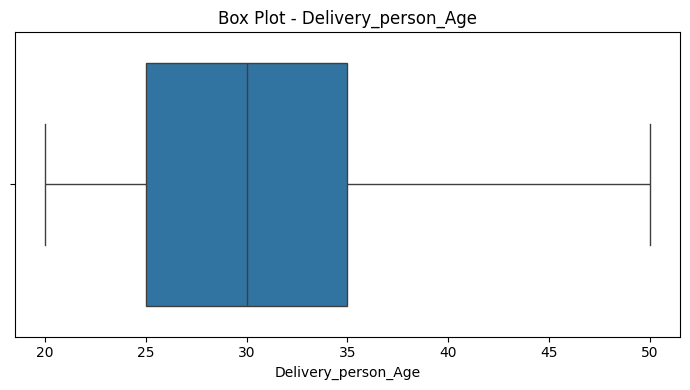

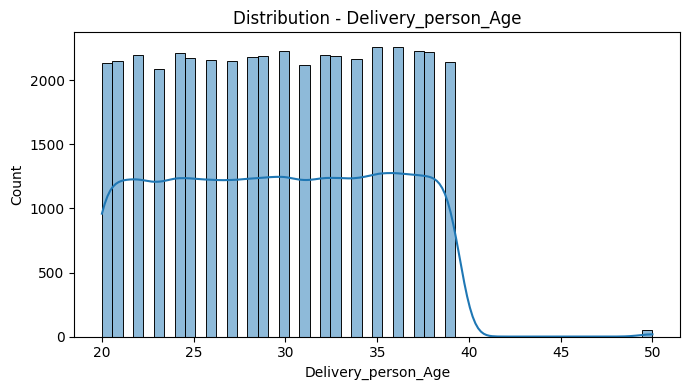

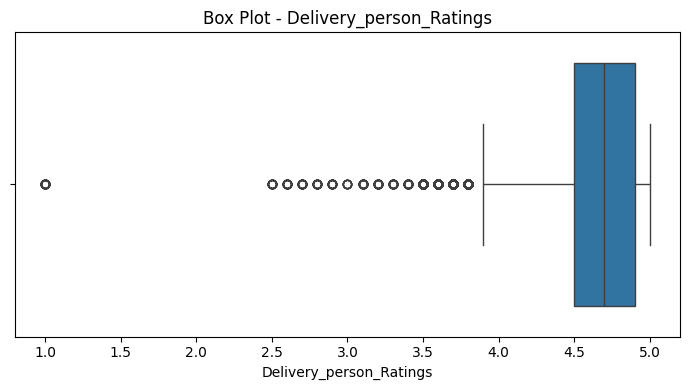

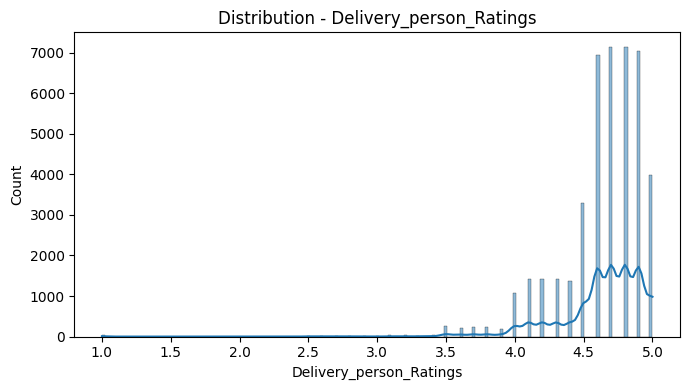

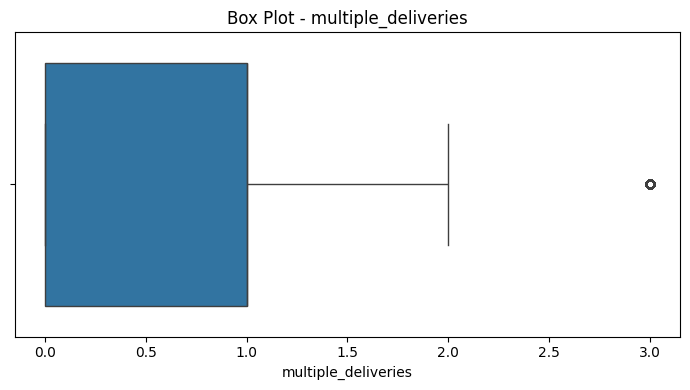

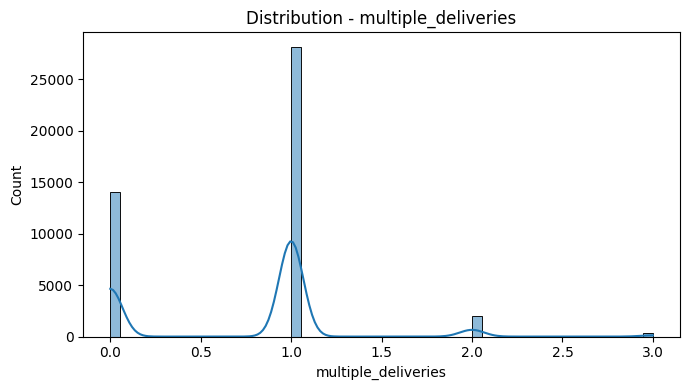

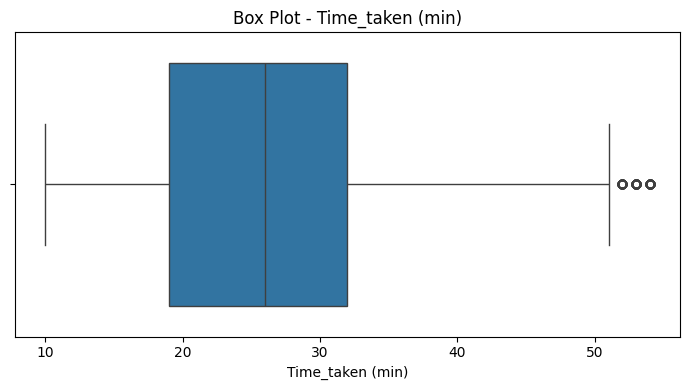

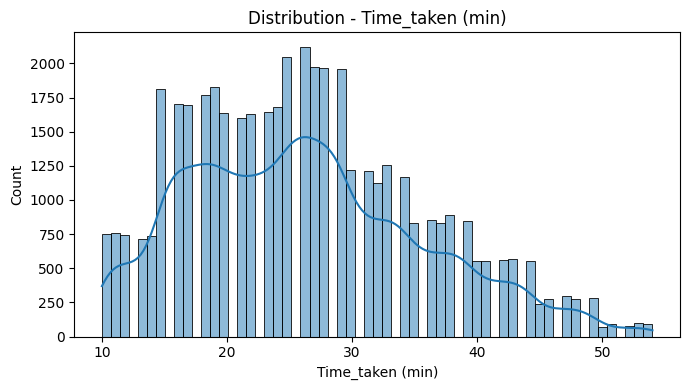

In [14]:
# Histograms and box plots for the main numeric variables
outlier_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Time_taken (min)"
]

for col in outlier_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot - {col}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution - {col}")
    plt.tight_layout()
    plt.show()

### IQR outlier flag

Outliers are **flagged first rather than automatically deleted**. This is important because a valid but unusual delivery can still contain useful information for the prediction model.

In [15]:
def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper

for col in outlier_cols:
    mask, lower, upper = iqr_outlier_mask(df[col].dropna())
    print(f"{col}: IQR bounds = ({lower:.2f}, {upper:.2f})")
    print(f"Potential IQR outliers: {mask.sum()}")

Delivery_person_Age: IQR bounds = (10.00, 50.00)
Potential IQR outliers: 0
Delivery_person_Ratings: IQR bounds = (3.90, 5.50)
Potential IQR outliers: 1170
multiple_deliveries: IQR bounds = (-1.50, 2.50)
Potential IQR outliers: 361
Time_taken (min): IQR bounds = (-0.50, 51.50)
Potential IQR outliers: 270


### Outlier treatment

After flagging, outliers are now actually treated instead of only being counted:

- **`Delivery_person_Age`**: no IQR outliers remain after the earlier 18–50 validity check, so no further action is needed.
- **`Delivery_person_Ratings`** and **`multiple_deliveries`** are predictor features, so extreme values are **capped (winsorized)** to the IQR bounds instead of dropping the row — this keeps the delivery record (and its other feature values) usable. *Note: `Delivery_person_Ratings` is naturally skewed toward high ratings, so the IQR rule also caps some legitimately low ratings up toward the lower bound — this is a known trade-off of applying IQR to a skewed, bounded scale.*
- **`Time_taken (min)`** is the target variable. Capping it would artificially rewrite the ground-truth delivery time, which is not appropriate for a regression target, so rows with an outlier target value are **removed** instead.


In [16]:
# Cap predictor outliers (winsorize) so the rest of the row is not lost
ratings_mask, ratings_lower, ratings_upper = iqr_outlier_mask(df["Delivery_person_Ratings"].dropna())
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].clip(ratings_lower, ratings_upper)

md_mask, md_lower, md_upper = iqr_outlier_mask(df["multiple_deliveries"].dropna())
df["multiple_deliveries"] = df["multiple_deliveries"].clip(md_lower, md_upper).round()

print(f"Delivery_person_Ratings capped to ({ratings_lower:.2f}, {ratings_upper:.2f})")
print(f"multiple_deliveries capped to ({md_lower:.2f}, {md_upper:.2f}) and rounded")

# Remove rows with an outlier target value (capping the target would distort ground truth)
target_mask, target_lower, target_upper = iqr_outlier_mask(df["Time_taken (min)"])
rows_before = len(df)
df = df[~target_mask].reset_index(drop=True)
rows_after = len(df)

print(f"\nTime_taken (min) IQR bounds: ({target_lower:.2f}, {target_upper:.2f})")
print(f"Rows removed due to Time_taken (min) outliers: {rows_before - rows_after}")
print("Shape after outlier treatment:", df.shape)


Delivery_person_Ratings capped to (3.90, 5.50)
multiple_deliveries capped to (-1.50, 2.50) and rounded

Time_taken (min) IQR bounds: (-0.50, 51.50)
Rows removed due to Time_taken (min) outliers: 270
Shape after outlier treatment: (45314, 24)


In [17]:
# Re-check: outliers should now be gone (or greatly reduced) for the treated columns
for col in outlier_cols:
    mask, lower, upper = iqr_outlier_mask(df[col].dropna())
    print(f"{col}: IQR bounds = ({lower:.2f}, {upper:.2f})  |  remaining outliers: {mask.sum()}")


Delivery_person_Age: IQR bounds = (10.00, 50.00)  |  remaining outliers: 0
Delivery_person_Ratings: IQR bounds = (3.90, 5.50)  |  remaining outliers: 0
multiple_deliveries: IQR bounds = (-1.50, 2.50)  |  remaining outliers: 0
Time_taken (min): IQR bounds = (-0.50, 51.50)  |  remaining outliers: 0


## 8. Structural / tidy-data checks

In [18]:
# Confirm one observation per row and one variable per column
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate IDs:", df["ID"].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())

# Check for encoding/mojibake-like characters in object columns
# (NaN values are dropped first since they are not strings and would break the check)
suspicious_patterns = ["Ã", "Â", "â€™", "â€“", "�"]
for col in df.select_dtypes(include="object").columns:
    count = df[col].dropna().astype(str).apply(
        lambda x: any(p in x for p in suspicious_patterns)
    ).sum()
    if count:
        print(f"{col}: {count} suspiciously encoded values")


Rows: 45314
Columns: 24
Duplicate IDs: 0
Duplicate full rows: 0


## 9. Final missing-value treatment

In [19]:
# Median imputation for numeric variables
numeric_impute_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

for col in numeric_impute_cols:
    df[col] = df[col].fillna(df[col].median())

# Explicit Unknown category for categorical missing values
categorical_fill_cols = [
    "Weather_conditions",
    "Road_traffic_density",
    "Festival",
    "City"
]

for col in categorical_fill_cols:
    df[col] = df[col].fillna("Unknown")

# Time strings are no longer needed after extracting numeric time features.
df = df.drop(columns=["Time_Orderd_clean", "Time_Order_picked_clean"], errors="ignore")

print("Remaining missing values:")
remaining_missing = df.isna().sum()
display(remaining_missing[remaining_missing > 0])

Remaining missing values:


,0
Time_Orderd,1716
Order_time_minutes,1716
Picked_time_minutes,880


## 10. Final validation

In [20]:
print("Final shape:", df.shape)

print("\nFinal data types:")
display(df.dtypes.to_frame("dtype"))

print("\nFinal summary statistics:")
display(df.describe(include="all").T)

print("\nRandom cleaned sample:")
display(df.sample(10, random_state=42))

print("\nFinal duplicate count:", df.duplicated().sum())

Final shape: (45314, 22)

Final data types:


,dtype
ID,object
Delivery_person_ID,object
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,datetime64[ns]
Time_Orderd,object



Final summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,45314,45314,0x5fb2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_ID,45314,1320,PUNERES01DEL01,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_Age,45314.0,NaN,NaN,NaN,29.581895,20.0,25.0,30.0,34.0,50.0,5.681838
Delivery_person_Ratings,45314.0,NaN,NaN,NaN,4.647714,3.9,4.6,4.7,4.8,5.0,0.2728
Restaurant_latitude,45314.0,NaN,NaN,NaN,18.922888,9.957144,13.029198,19.065838,22.732225,30.914057,5.2445
Restaurant_longitude,45314.0,NaN,NaN,NaN,76.897798,72.768726,73.915367,76.618203,78.046106,88.433452,3.359382
Delivery_location_latitude,45314.0,NaN,NaN,NaN,18.985925,9.967144,13.095801,19.123249,22.785049,31.054057,5.246197
Delivery_location_longitude,45314.0,NaN,NaN,NaN,76.959834,72.778726,74.006485,76.663067,78.106809,88.563452,3.359669
Order_Date,45314,NaN,NaN,NaN,2022-03-13 16:22:36.931632640,2022-02-11 00:00:00,2022-03-04 00:00:00,2022-03-15 00:00:00,2022-03-27 00:00:00,2022-04-06 00:00:00,NaN
Time_Orderd,43598,176,17:55,456,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Random cleaned sample:


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),Order_time_minutes,Picked_time_minutes
26944,0x8267,MUMRES15DEL03,32.0,4.3,19.176269,72.836721,19.266269,72.926721,2022-03-29,20:25,20:30,Sandstorms,Jam,2,Snack,scooter,1.0,No,Metropolitian,43,1225.0,1230.0
11682,0x57d2,BANGRES03DEL02,31.0,5.0,12.979166,77.640709,13.109166,77.770709,2022-03-04,23:55,1,Stormy,Low,1,Drinks,motorcycle,1.0,No,Urban,22,1435.0,0.0
9961,0xc52c,LUDHRES02DEL02,20.0,4.6,19.065838,76.618203,19.123249,76.663067,2022-02-12,18:35,18:40,Windy,Medium,0,Meal,motorcycle,0.0,No,Metropolitian,26,1115.0,1120.0
31578,0x4890,BANGRES19DEL02,30.0,5.0,12.914264,77.678400,12.964264,77.728400,2022-04-05,1,24:15:00,Sunny,Low,2,Snack,motorcycle,0.0,No,Urban,15,0.0,NaN
37768,0xcfbe,DEHRES03DEL03,39.0,4.6,30.335259,78.053162,30.395259,78.113162,2022-02-15,21:55,0.916666667,Cloudy,Jam,2,Meal,scooter,0.0,No,Urban,30,1315.0,1320.0
37615,0x5775,SURRES19DEL01,37.0,4.7,21.149669,72.772629,21.259669,72.882629,2022-04-02,21:15,21:20,Cloudy,Jam,2,Buffet,scooter,2.0,No,Metropolitian,48,1275.0,1280.0
8801,0xa93e,BANGRES05DEL02,21.0,4.5,12.970324,77.645748,13.050324,77.725748,2022-03-08,22:50,23:05,Fog,Low,1,Buffet,scooter,1.0,No,Metropolitian,21,1370.0,1385.0
14768,0xa5cb,INDORES17DEL03,22.0,4.5,22.761226,75.887522,22.821226,75.947522,2022-04-05,23:15,23:25,Stormy,Low,1,Meal,scooter,0.0,No,Metropolitian,18,1395.0,1405.0
11500,0xd470,BHPRES20DEL01,27.0,5.0,23.235123,77.398886,23.275123,77.438886,2022-02-17,13:40,13:45,Windy,High,1,Snack,motorcycle,1.0,No,Metropolitian,13,820.0,825.0
16912,0xcfc2,ALHRES15DEL02,39.0,4.5,25.449872,81.836167,25.579872,81.966167,2022-02-16,19:15,19:20,Sandstorms,Jam,2,Snack,electric_scooter,1.0,No,Metropolitian,29,1155.0,1160.0



Final duplicate count: 0


## 11. Save the cleaned dataset

In [21]:
import os

# Save next to /content on Colab, or in the local working directory otherwise
if os.path.isdir("/content"):
    cleaned_path = "/content/Zomato_Cleaned_Dareen.csv"
else:
    cleaned_path = "Zomato_Cleaned_Dareen.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved to:", cleaned_path)


Cleaned dataset saved to: /content/Zomato_Cleaned_Dareen.csv


# Part A – Exploratory Data Analysis (EDA)

Before moving to the Decision Tree Regressor, this section explores the cleaned dataset with individual plots covering the target variable, numeric features, categorical features, and their relationship with delivery time.


## 1. Target variable: `Time_taken (min)`

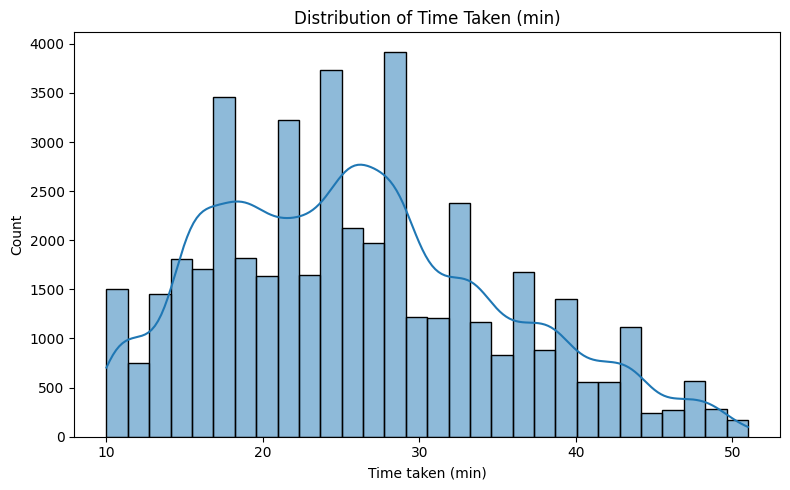

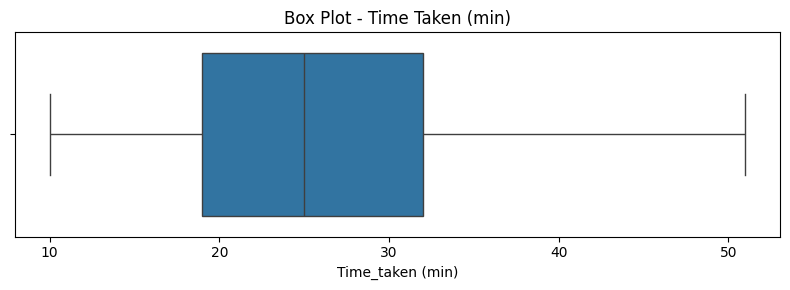

count    45314.000000
mean        26.134572
std          9.181327
min         10.000000
25%         19.000000
50%         25.000000
75%         32.000000
max         51.000000
Name: Time_taken (min), dtype: float64


In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Time_taken (min)"], kde=True, bins=30)
plt.title("Distribution of Time Taken (min)")
plt.xlabel("Time taken (min)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df["Time_taken (min)"])
plt.title("Box Plot - Time Taken (min)")
plt.tight_layout()
plt.show()

print(df["Time_taken (min)"].describe())


## 2. Numeric feature distributions

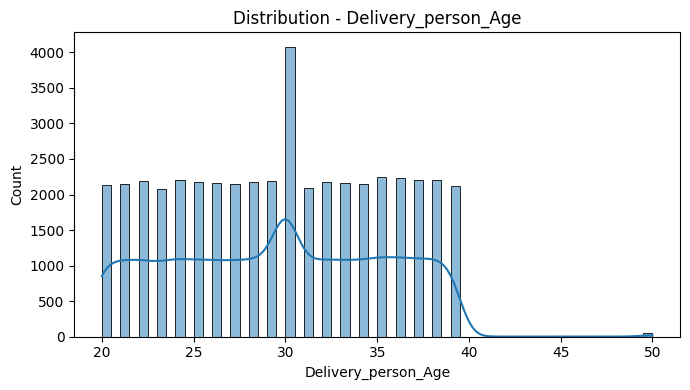

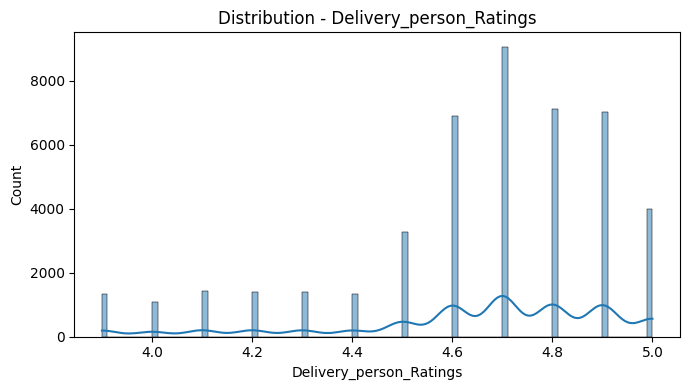

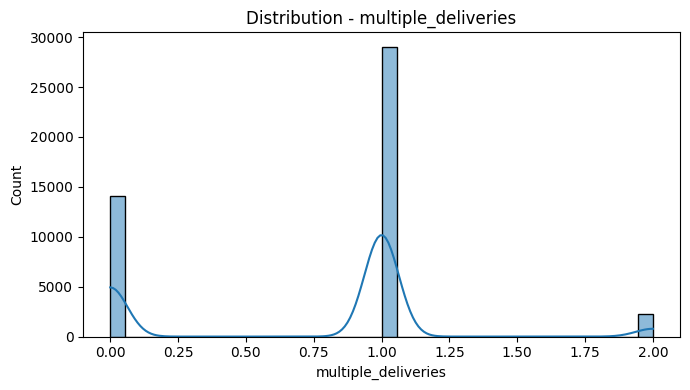

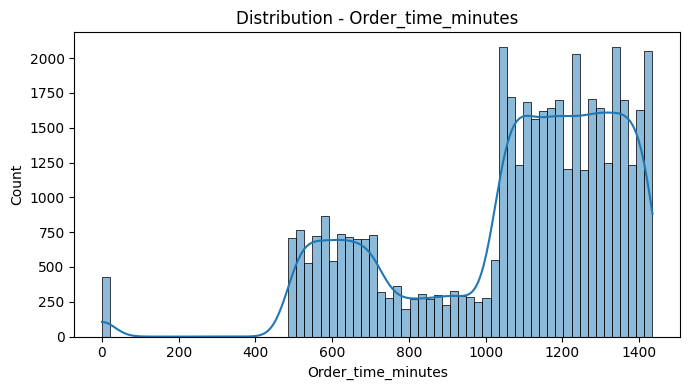

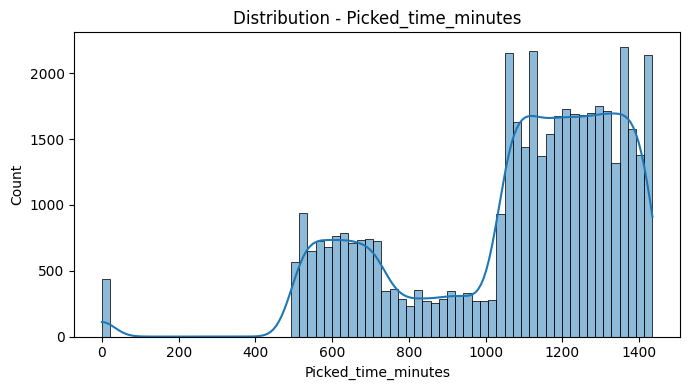

In [23]:
numeric_dist_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "Order_time_minutes",
    "Picked_time_minutes"
]

for col in numeric_dist_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution - {col}")
    plt.tight_layout()
    plt.show()


## 3. Correlation between numeric features and delivery time

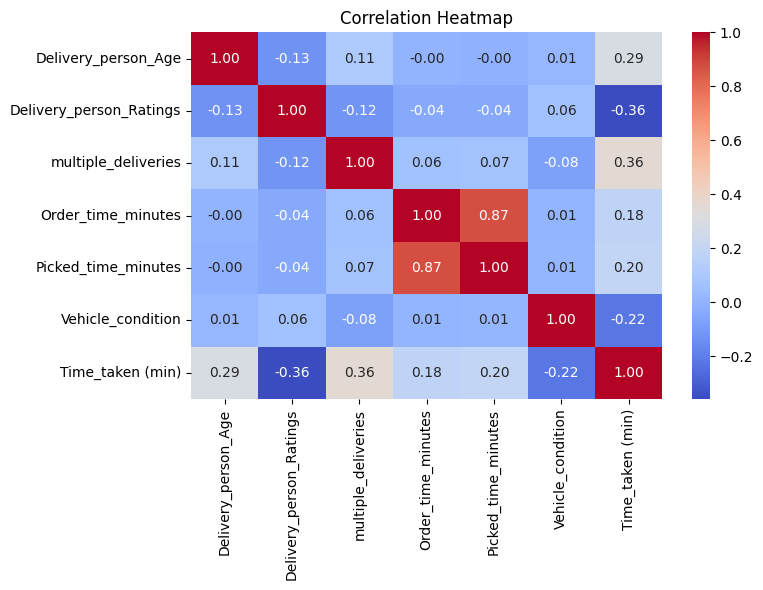

In [24]:
corr_cols = numeric_dist_cols + ["Vehicle_condition", "Time_taken (min)"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 4. Categorical feature frequencies

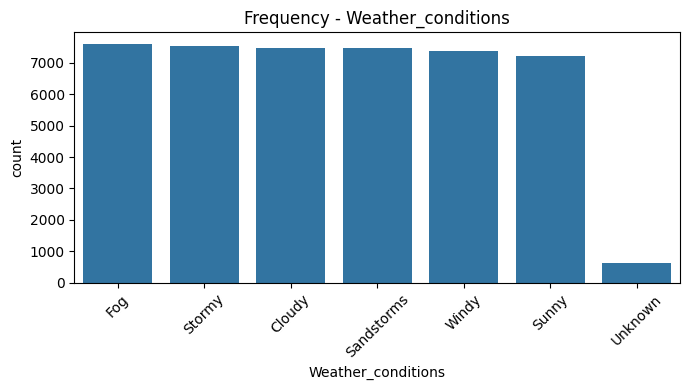

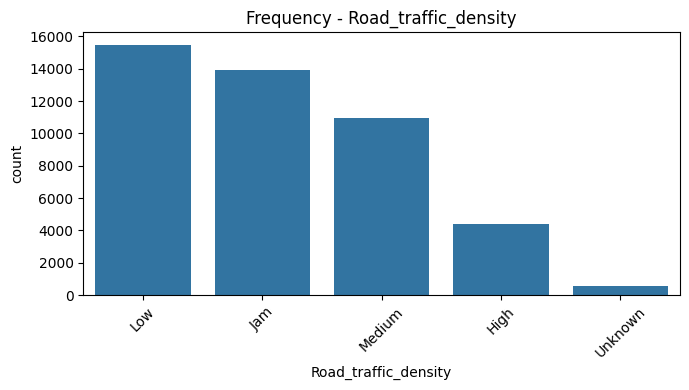

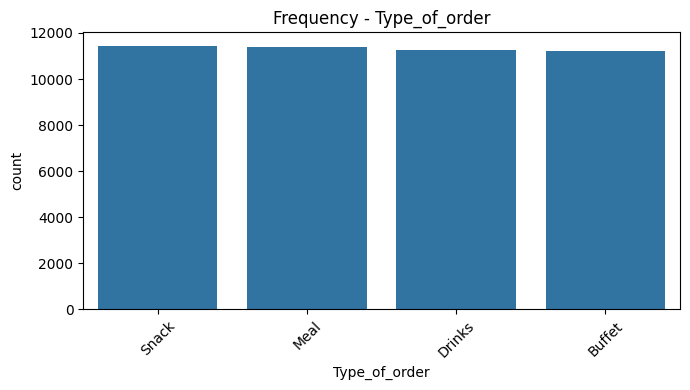

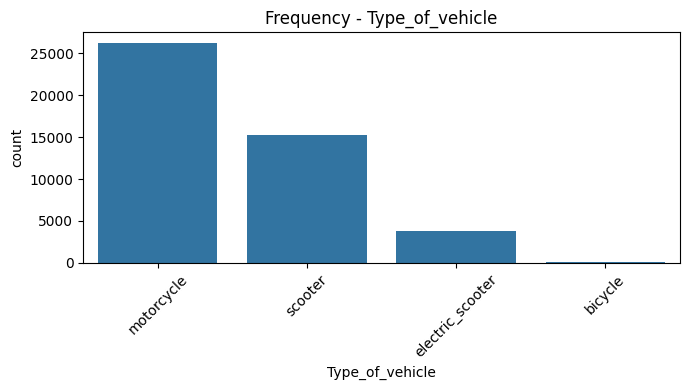

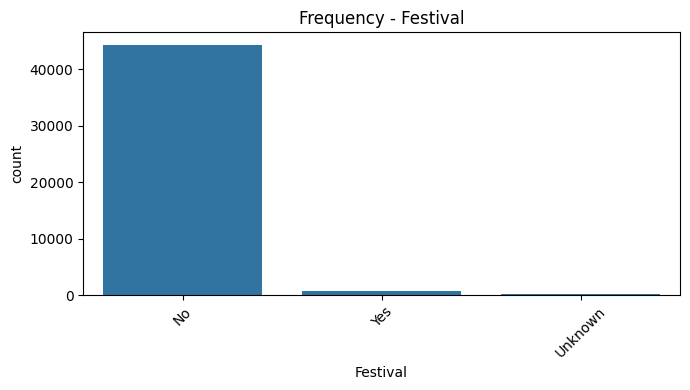

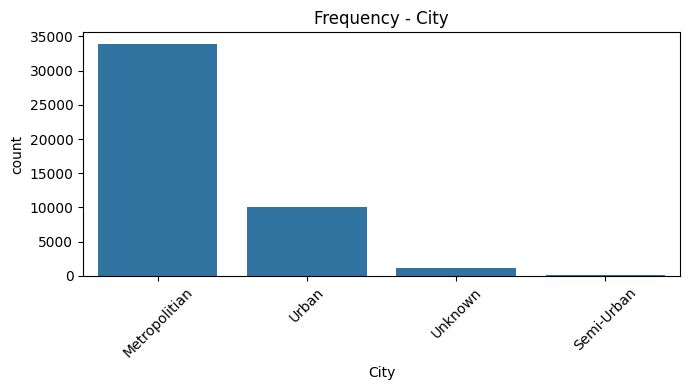

In [25]:
categorical_eda_cols = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

for col in categorical_eda_cols:
    plt.figure(figsize=(7, 4))
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order)
    plt.title(f"Frequency - {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 5. Delivery time vs. categorical features

Box plots show how `Time_taken (min)` varies across the main categorical drivers (traffic, weather, festival, city, vehicle type, order type). Since a box plot's whiskers are computed **per category**, a value can still look like an outlier inside its own group even though the global `Time_taken (min)` outliers were already removed earlier. To keep these plots readable, points that are outliers **within their own category** (per-category IQR) are filtered out just for this visualization — the underlying `df` used for modeling later is left untouched.


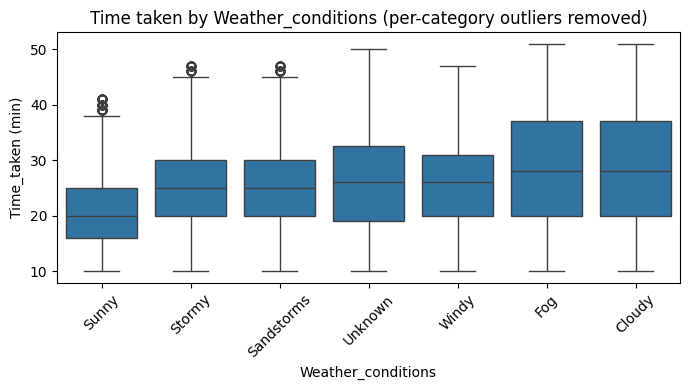

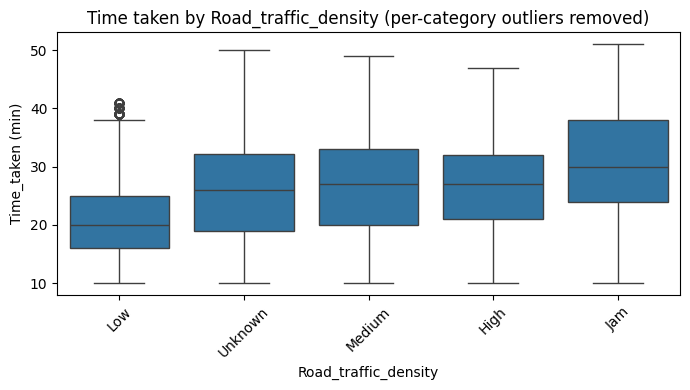

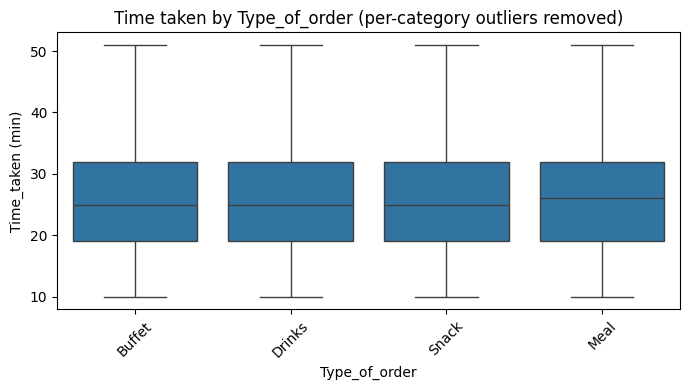

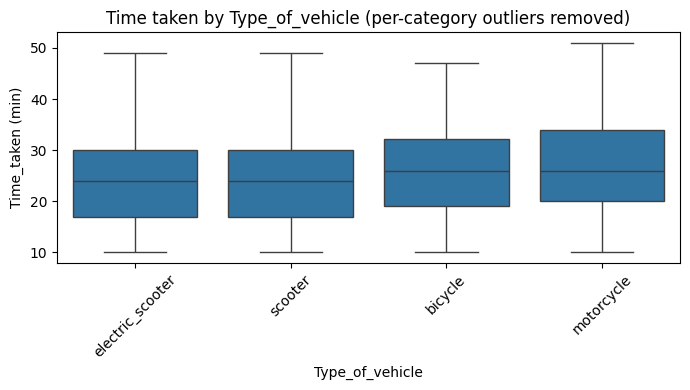

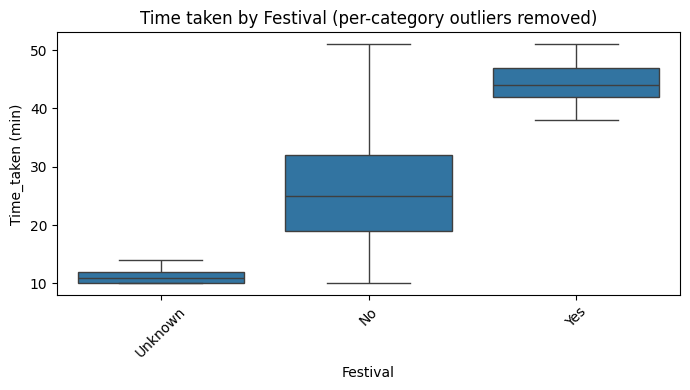

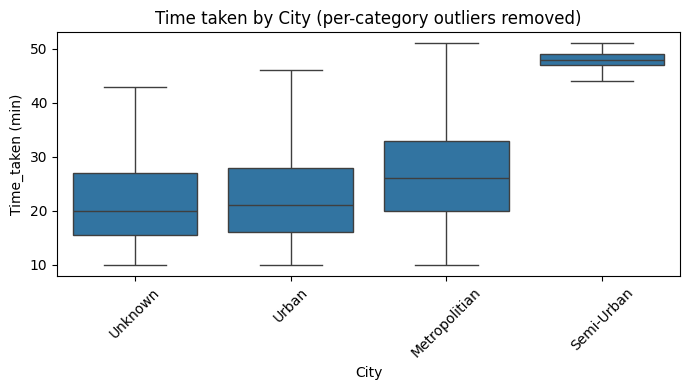

In [26]:
def remove_outliers_per_group(data, group_col, value_col):
    """Drop rows that are IQR outliers *within their own category*, for plotting only."""
    def filter_group(g):
        q1 = g[value_col].quantile(0.25)
        q3 = g[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return g[g[value_col].between(lower, upper)]
    return data.groupby(group_col, group_keys=False)[[group_col, value_col]].apply(filter_group)

for col in categorical_eda_cols:
    plot_data = remove_outliers_per_group(df, col, "Time_taken (min)")
    plt.figure(figsize=(7, 4))
    order = plot_data.groupby(col)["Time_taken (min)"].median().sort_values().index
    sns.boxplot(x=col, y="Time_taken (min)", data=plot_data, order=order)
    plt.title(f"Time taken by {col} (per-category outliers removed)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 6. Delivery time vs. numeric features

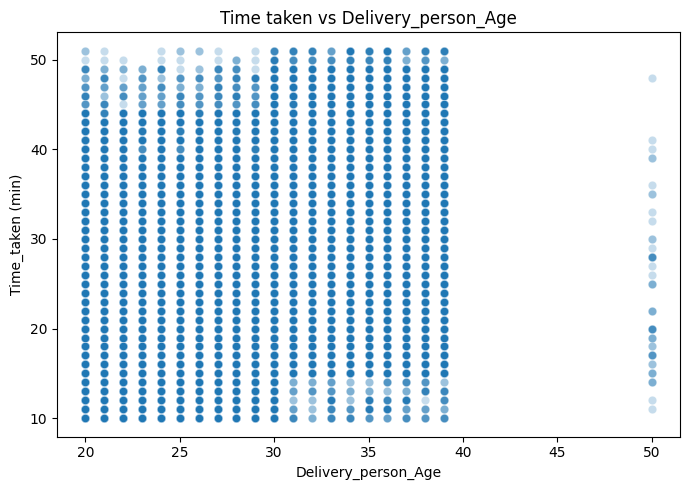

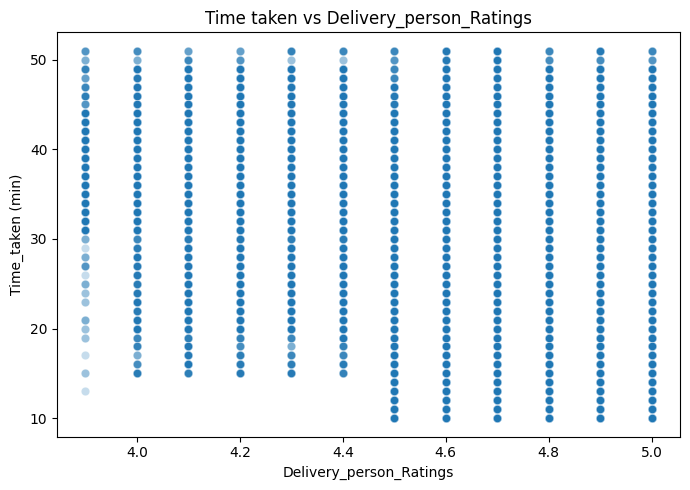

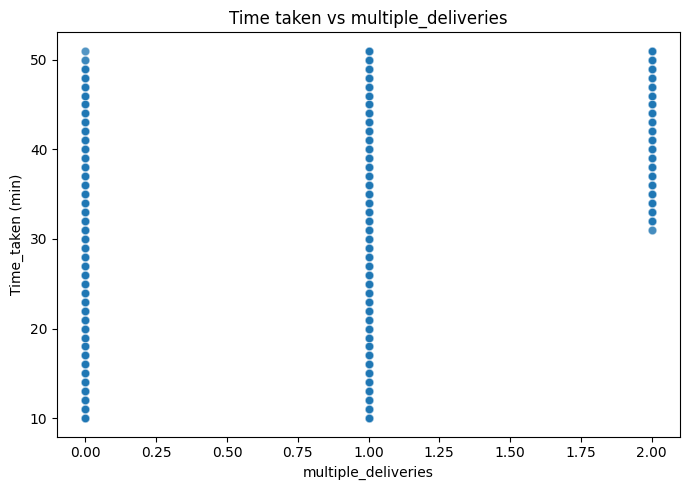

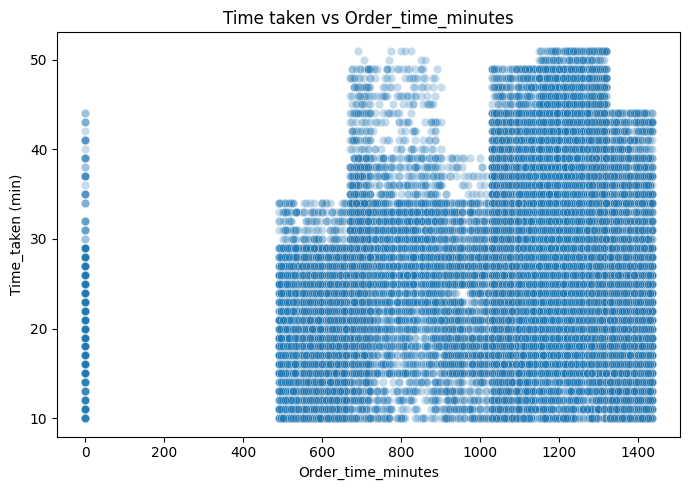

In [27]:
scatter_cols = ["Delivery_person_Age", "Delivery_person_Ratings",
                "multiple_deliveries", "Order_time_minutes"]

for col in scatter_cols:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x=df[col], y=df["Time_taken (min)"], alpha=0.25)
    plt.title(f"Time taken vs {col}")
    plt.tight_layout()
    plt.show()


## 7. EDA summary

- `Time_taken (min)` is roughly bell-shaped with a slight right skew and no extreme outliers after the earlier cleaning/outlier-flagging step.
- `Road_traffic_density` and `Festival` show the clearest separation in median delivery time — Jam traffic and Festival days are associated with longer deliveries.
- `Delivery_person_Ratings` shows a mild negative relationship with delivery time (higher-rated drivers tend to be a bit faster).
- `Delivery_person_Age` and `multiple_deliveries` show weaker but visible positive relationships with delivery time.
- These patterns motivate testing tree-based models (like the Decision Tree Regressor below), which can naturally capture non-linear effects and interactions between categorical and numeric features.


# Feature Engineering


1) **Distance** (haversine formula) — replaces raw lat/long as a single, more
learnable feature for all models

In [28]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine_distance(
    df["Restaurant_latitude"], df["Restaurant_longitude"],
    df["Delivery_location_latitude"], df["Delivery_location_longitude"]
)

- Sanity check: distance should be plausible (not 0, not thousands of km)

In [29]:
print("\nDistance summary (km):")
print(df["distance_km"].describe())


Distance summary (km):
count    45314.000000
mean         9.558093
std          5.394377
min          1.465067
25%          5.860430
50%          8.937864
75%         13.406506
max         20.969489
Name: distance_km, dtype: float64


2) time-based features
- Order_time_minutes should already exist from the cleaning notebook (minutes after midnight the order was placed)

In [30]:
df["order_hour"] = (df["Order_time_minutes"] // 60).astype("Int64")
df["is_rush_hour"] = df["order_hour"].isin([12, 13, 19, 20]).astype(int)

- Day-of-week features from Order_Date

In [31]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["order_dayofweek"] = df["Order_Date"].dt.dayofweek
df["is_weekend"] = df["order_dayofweek"].isin([5, 6]).astype(int)

print("New features added: distance_km, order_hour, is_rush_hour, order_dayofweek, is_weekend")
print(df[["distance_km", "order_hour", "is_rush_hour", "order_dayofweek", "is_weekend"]].describe(include="all"))

New features added: distance_km, order_hour, is_rush_hour, order_dayofweek, is_weekend
        distance_km  order_hour  is_rush_hour  order_dayofweek    is_weekend
count  45314.000000     43598.0  45314.000000     45314.000000  45314.000000
mean       9.558093   17.412175      0.235181         2.997617      0.274970
std        5.394377    4.826364      0.424117         1.969700      0.446504
min        1.465067         0.0      0.000000         0.000000      0.000000
25%        5.860430        15.0      0.000000         1.000000      0.000000
50%        8.937864        19.0      0.000000         3.000000      0.000000
75%       13.406506        21.0      0.000000         5.000000      1.000000
max       20.969489        23.0      1.000000         6.000000      1.000000


- Prep time = how long the restaurant took before handoff to the delivery person
- Handle wraparound if an order was placed just before midnight and picked up just after (negative values from the subtraction)

In [32]:
df["prep_time_minutes"] = df["Picked_time_minutes"] - df["Order_time_minutes"]

df.loc[df["prep_time_minutes"] < 0, "prep_time_minutes"] += 24 * 60

print(df["prep_time_minutes"].describe())

count    42757.000000
mean         9.957200
std          4.084979
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: prep_time_minutes, dtype: float64


In [33]:
# Features selected for modeling — updated to use engineered features
features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "distance_km",
    "order_hour",
    "is_rush_hour",
    "order_dayofweek",
    "is_weekend",
    "prep_time_minutes",   # add this
    "Weather_conditions",
    "Road_traffic_density",
    "Vehicle_condition",
    "Type_of_order",
    "Type_of_vehicle",
    "multiple_deliveries",
    "Festival",
    "City",
]

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "distance_km",
    "order_hour",
    "is_rush_hour",
    "order_dayofweek",
    "is_weekend",
    "Vehicle_condition",
    "multiple_deliveries",
    "prep_time_minutes",
    # "Picked_time_minutes" removed — replaced by prep_time_minutes
]

categorical_features = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City",
]

# Part B – Decision Tree Regressor

The target is `Time_taken (min)`.

The model uses the cleaned numerical and categorical features. Categorical features are one-hot encoded and missing values are handled inside the pipeline so the preprocessing is reproducible and avoids data leakage.

In [34]:
target = "Time_taken (min)"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (36251, 16)
Test shape: (9063, 16)


## 12. Train a baseline Decision Tree

In [35]:
dt_pipeline.fit(X_train, y_train)

y_pred = dt_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Decision Tree Baseline")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

Decision Tree Baseline
MAE : 4.262
RMSE: 5.655
R²  : 0.630


## 13. Decision Tree tuning

Grid search is used to tune tree complexity. The goal is to reduce overfitting while improving validation performance.

In [36]:
param_grid = {
    "model__max_depth": [5, 8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

grid_search = GridSearchCV(
    dt_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best CV RMSE: {-grid_search.best_score_:.3f}")

Best parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
Best CV RMSE: 4.328


## 14. Evaluate the tuned Decision Tree

In [37]:
best_dt = grid_search.best_estimator_
y_pred_tuned = best_dt.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

dt_results = pd.DataFrame({
    "Model": ["Decision Tree - Tuned"],
    "MAE": [mae_tuned],
    "RMSE": [rmse_tuned],
    "R2": [r2_tuned]
})

display(dt_results)

,Model,MAE,RMSE,R2
0,Decision Tree - Tuned,3.378057,4.333443,0.782453


## 15. Actual vs predicted delivery time

A scatter plot helps check how close the model's predictions are to the real delivery times.

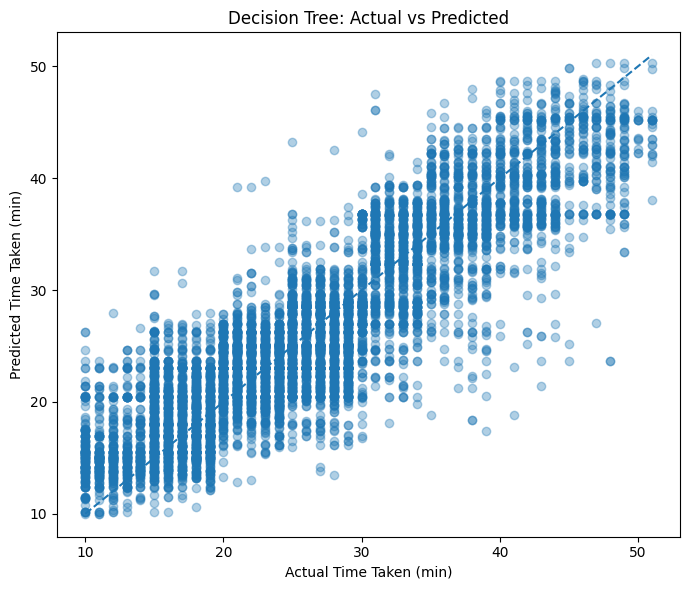

In [38]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.35)

min_val = min(y_test.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Time Taken (min)")
plt.ylabel("Predicted Time Taken (min)")
plt.title("Decision Tree: Actual vs Predicted")
plt.tight_layout()
plt.show()

# Part C – Linear Regression (comparison model)

A Linear Regression model is trained on the exact same train/test split and target (`Time_taken (min)`) as the Decision Tree, so the two models can be compared fairly. Numeric features are standardized (mean 0, std 1) since, unlike a Decision Tree, Linear Regression is sensitive to feature scale. Categorical features use the same one-hot encoding.


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

lr_pipeline = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"MAE : {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²  : {r2_lr:.3f}")


Linear Regression
MAE : 4.771
RMSE: 6.001
R²  : 0.583


## Actual vs predicted delivery time (Linear Regression)

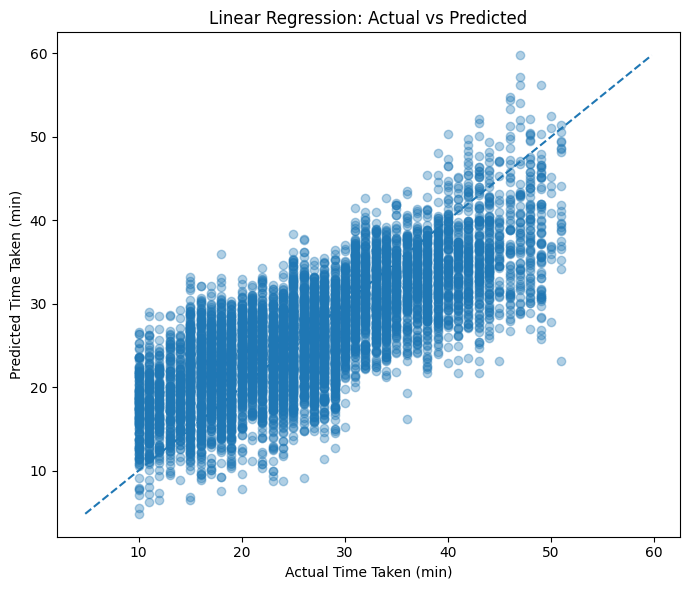

In [40]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.35)

min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Time Taken (min)")
plt.ylabel("Predicted Time Taken (min)")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()


## Decision Tree vs Linear Regression

In [41]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_lr],
    "RMSE": [rmse_lr],
    "R2": [r2_lr]
})

model_comparison = pd.concat([dt_results, lr_results], ignore_index=True)
display(model_comparison)


,Model,MAE,RMSE,R2
0,Decision Tree - Tuned,3.378057,4.333443,0.782453
1,Linear Regression,4.771415,6.001154,0.582788


# Part D – Random Forest (main model)

A Random Forest Regressor is trained on the same features, train/test split,
and target as the Decision Tree and Linear Regression models, to compare a
tree ensemble against a single tree and a linear baseline. Since it's
tree-based, it doesn't require feature scaling (same as the Decision Tree).


- Random Forest model (baseline + tuning + evaluation):

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),   # reuses the same preprocessor as the Decision Tree
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Baseline fit
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Baseline")
print(f"MAE : {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"R²  : {r2_score(y_test, y_pred_rf):.3f}")

Random Forest Baseline
MAE : 3.243
RMSE: 4.129
R²  : 0.802


- hyperparameter tuning

In [43]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [1, 2, 5],
}

rf_grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid_search.best_params_)
print(f"Best CV RMSE: {-rf_grid_search.best_score_:.3f}")

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best CV RMSE: 4.087


- final evaluation

In [44]:
best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_results = pd.DataFrame({
    "Model": ["Random Forest - Tuned"],
    "MAE": [mean_absolute_error(y_test, y_pred_rf_tuned)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))],
    "R2": [r2_score(y_test, y_pred_rf_tuned)]
})

display(rf_results)

,Model,MAE,RMSE,R2
0,Random Forest - Tuned,3.219338,4.079978,0.807157


# actual vs predicted plot

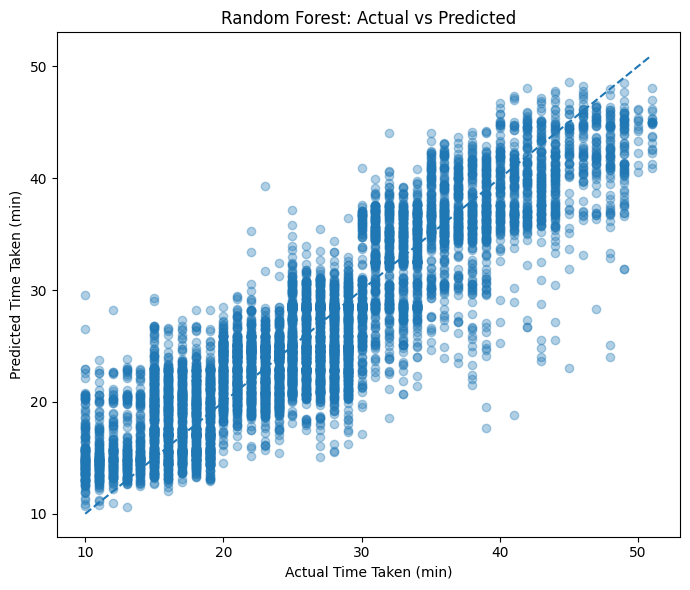

In [45]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf_tuned, alpha=0.35)

min_val = min(y_test.min(), y_pred_rf_tuned.min())
max_val = max(y_test.max(), y_pred_rf_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Time Taken (min)")
plt.ylabel("Predicted Time Taken (min)")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

In [46]:
feature_names = (
    numeric_features
    + list(best_rf.named_steps["preprocessor"]
           .named_transformers_["cat"]
           .named_steps["onehot"]
           .get_feature_names_out(categorical_features))
)
importances = best_rf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 most important features:")
display(importance_df.head(10))

Top 10 most important features:


,feature,importance
1,Delivery_person_Ratings,0.230567
19,Road_traffic_density_Low,0.141018
2,distance_km,0.111611
8,multiple_deliveries,0.111417
0,Delivery_person_Age,0.091629
7,Vehicle_condition,0.078658
14,Weather_conditions_Sunny,0.075315
11,Weather_conditions_Fog,0.043505
10,Weather_conditions_Cloudy,0.042902
18,Road_traffic_density_Jam,0.012823


In [47]:
model_comparison = pd.concat([dt_results, lr_results, rf_results], ignore_index=True)
display(model_comparison)

,Model,MAE,RMSE,R2
0,Decision Tree - Tuned,3.378057,4.333443,0.782453
1,Linear Regression,4.771415,6.001154,0.582788
2,Random Forest - Tuned,3.219338,4.079978,0.807157


## 16. Final notes for the report

**Data Cleaning:** Invalid ages and ratings were converted to missing values and then imputed using robust numeric statistics. Date/time fields were converted into consistent formats, categorical values were standardized, exact duplicates were removed, and geographic placeholders/sign errors were handled using domain-validity checks. Outliers were investigated with the IQR rule: predictor outliers (`Delivery_person_Ratings`, `multiple_deliveries`) were capped, and rows with an outlier target value (`Time_taken (min)`) were removed.

**Decision Tree:** A Decision Tree Regressor was trained to predict `Time_taken (min)`. Hyperparameters were tuned using cross-validation, and the final model was evaluated with MAE, RMSE, and R² on an untouched test set.

**Linear Regression:** A Linear Regression model was trained on the same train/test split for a direct comparison, with numeric features standardized before fitting.

**Random Forest:** A Random Forest Regressor was trained on the same features
and train/test split as the other two models, using an ensemble of decision
trees to reduce overfitting and capture feature interactions more robustly
than a single tree. Hyperparameters were tuned via cross-validation
(best parameters: max_depth=12, min_samples_leaf=2, n_estimators=200).

**Comparison:** The `model_comparison` table above places all three models
side by side. Random Forest achieved the best performance on every metric
(MAE 3.219, RMSE 4.080, R² 0.807), outperforming both the single Decision
Tree (R² 0.782) and Linear Regression (R² 0.583). This progression — linear
model → single tree → tree ensemble — supports the conclusion that delivery
time depends on non-linear interactions between features (e.g. traffic,
weather, festival, distance) that only tree-based models capture well.
Random Forest is recommended as the main model for this project, with the
Decision Tree and Linear Regression retained as justification/comparison
baselines.


In [53]:
import joblib

joblib.dump(best_rf, "rf_delivery_time_model.pkl")
print("Model saved to rf_delivery_time_model.pkl")

from google.colab import files
files.download("rf_delivery_time_model.pkl")

Model saved to rf_delivery_time_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>